# IXPLORE demo

This notebook demonstrates a compact workflow for using IXPLORE.

- Load example reaction data (binary or Likert-scale).
- Initialize and fit `IXPLORE` (with and without PCA initialization).
- Visualize the learned 2D embedding and decision boundaries for ssome questions.
- Embed a new user from partial answers and impute missing responses interpretably.
- Evaluate fit (MAE, accuracy) and examine model parameters.

Required packages: `numpy`, `pandas`, `scikit-learn`, `scipy`, `matplotlib`, and the local `ixplore` package (install with `pip install -e .`).


In [1]:
import numpy as np
import pandas as pd
from ixplore import IXPLORE
from ixplore.visualization import plot_overview, plot_posterior
from ixplore.utils import transformation_matrix

### Load data

This cell loads user metadata (for example colours or labels) used to annotate plots. Synthetic data was generated in notebooks/simulation.ipynb.

In [2]:
users = pd.read_csv('../data/synthetic_users.csv', index_col=0)
users

,x,y,party,noise,color
id,,,,,
0,-0.468,-0.583,0,0,C0
1,-0.244,-0.432,0,0,C0
2,-0.346,-0.412,0,0,C0
3,-0.514,-0.558,0,1,C0
4,-0.419,-0.586,0,4,C0
...,...,...,...,...,...
245,-0.154,0.210,4,1,C4
246,0.012,-0.171,4,1,C4
247,-0.079,-0.067,4,1,C4


This cell loads the user-item reaction matrix. For Likert data, IXPLORE automatically normalizes responses to the [0,1] range.

In [3]:
reactions = pd.read_csv('../data/likert_reactions.csv', index_col=0)
reactions

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,...,Q61,Q62,Q63,Q64,Q65,Q66,Q67,Q68,Q69,Q70
id,,,,,,,,,,,,,,,,,,,,,
0,1,2,3,0,3,1,2,3,2,3,...,0,2,2,1,2,2,3,1,2,2
1,1,2,3,0,3,1,2,3,2,3,...,0,2,2,1,2,2,3,1,2,2
2,1,2,3,0,3,1,1,2,2,3,...,0,2,2,1,2,2,3,1,2,2
3,1,2,3,0,3,1,2,3,2,3,...,0,2,2,1,2,2,3,0,2,2
4,1,2,3,0,3,1,2,3,2,3,...,0,2,2,1,2,2,3,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,2,2,3,1,3,2,0,0,2,1,...,3,2,0,2,2,2,2,2,1,0
246,1,3,2,0,3,1,1,1,1,2,...,1,1,2,2,1,2,2,3,2,0
247,2,2,2,0,3,1,1,1,2,2,...,2,2,1,2,2,2,2,2,1,0


## Train models

### Random initialization

In [4]:
xplore = IXPLORE(reactions, pca_initialization=False, random_state=17, sampling_resolution=100)


ixplore - INFO - 2026-03-14 13:07:45 - Number of users for model: 250
ixplore - INFO - 2026-03-14 13:07:45 - Number of items: 70
ixplore - INFO - 2026-03-14 13:07:45 - Number of missing values: 0 (0.00%)
ixplore - INFO - 2026-03-14 13:07:45 - Grid created with resolution 100x100, total 10000 points
ixplore - INFO - 2026-03-14 13:07:45 - Prior set with mean [0 0] and covariance [1 0 0 1]
ixplore - INFO - 2026-03-14 13:07:45 - Random state set to 17
ixplore - INFO - 2026-03-14 13:07:45 - Initialized embedding with random values.
ixplore - INFO - 2026-03-14 13:07:45 - Fitted model parameters from embedding.


We initialize the user positions randomly (left panel) and learn logistic regression models based on these positions (righ panel).

ixplore - INFO - 2026-03-14 13:07:45 - MAE: 0.2813, ACC: 0.6741


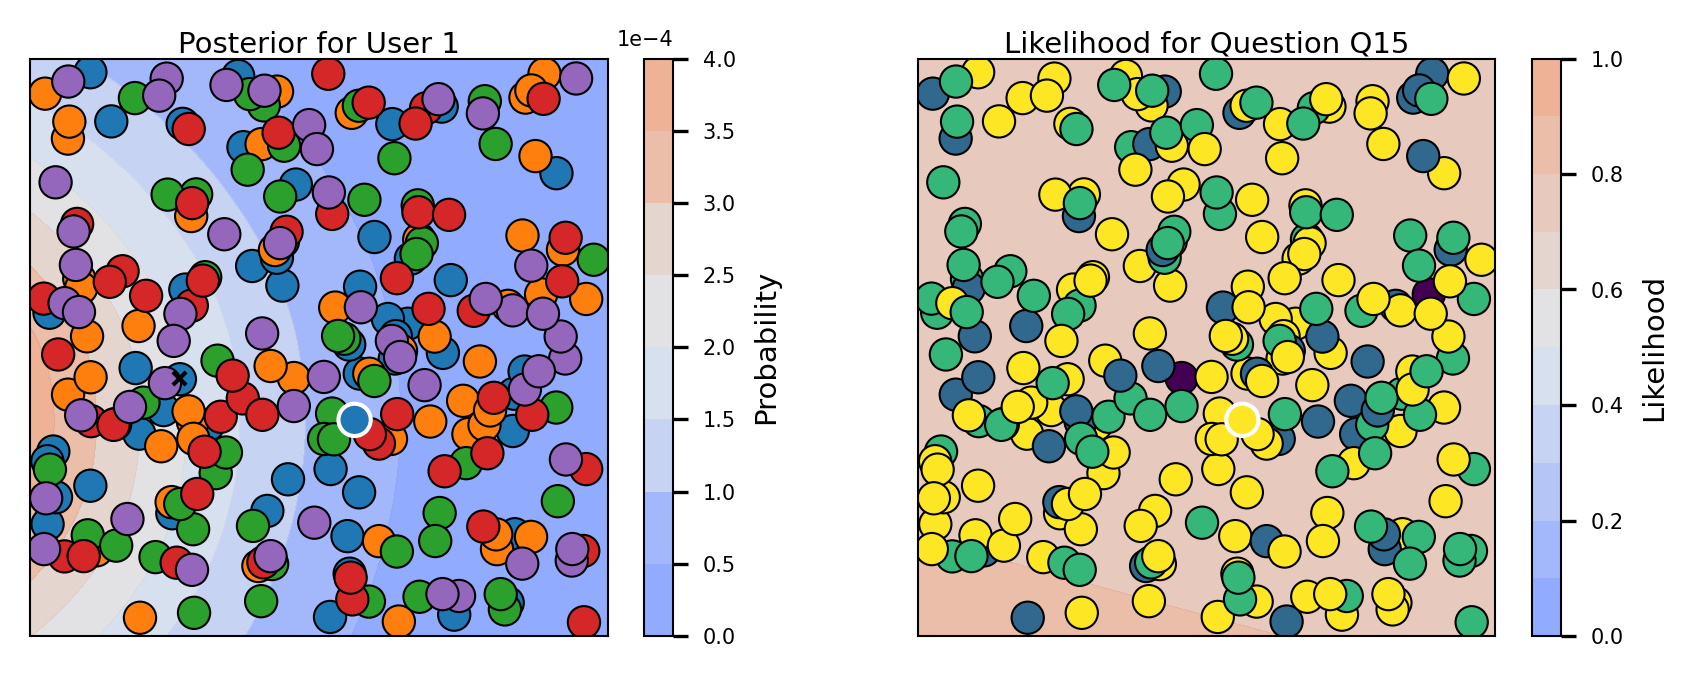

In [5]:
fig, (ax1, ax2) = plot_overview(xplore, question='Q15', user='1', colors=users.color)

We fit posterior distributions for all users using the current logistic regression models, then visualize the posterior for one example user.

ixplore - INFO - 2026-03-14 13:07:46 - MAE: 0.2687, ACC: 0.7050


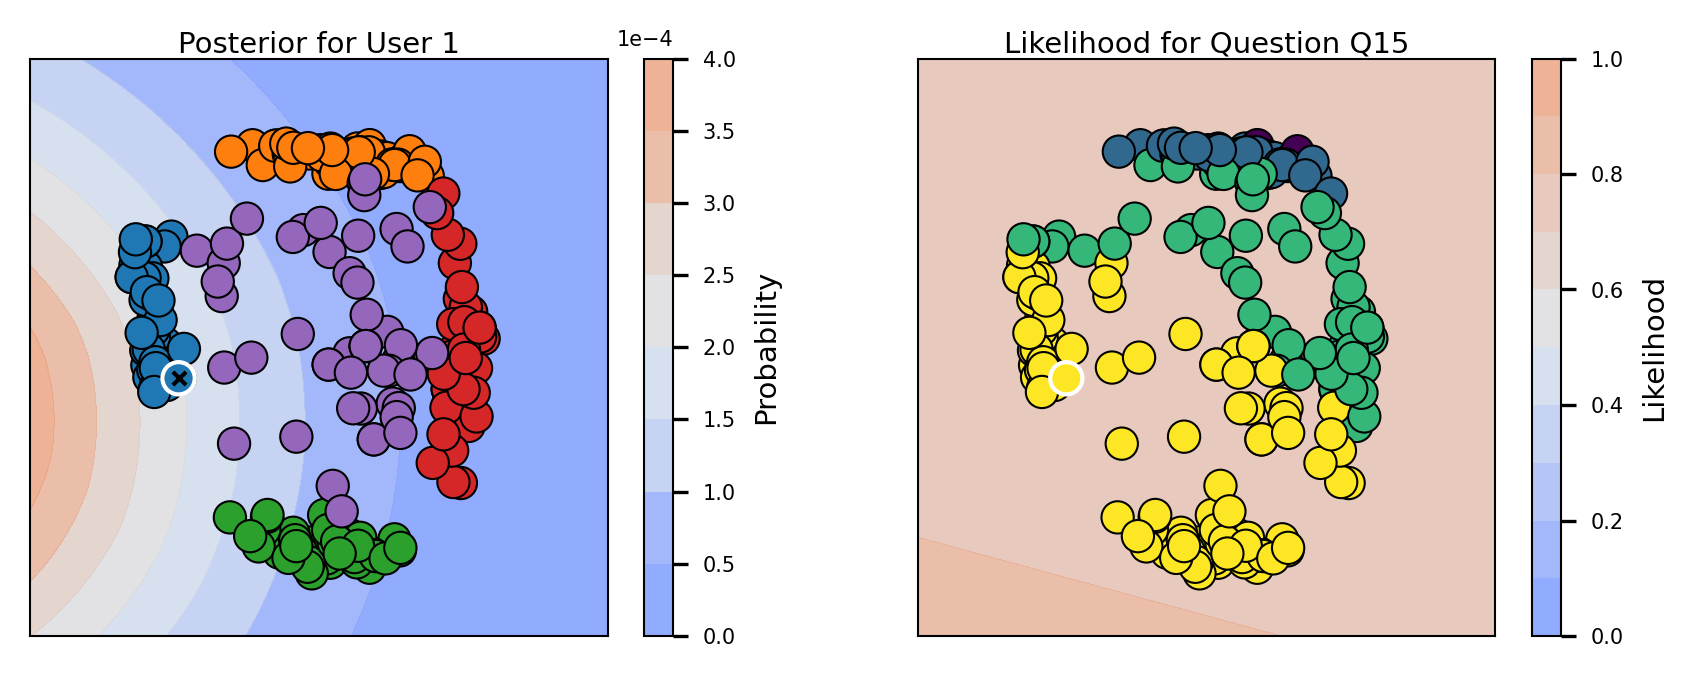

In [6]:
xplore.fit_posteriors()
fig, (ax1, ax2) = plot_overview(xplore, question='Q15', user='1', colors=users.color)

We fit logistic regression models for each question using the current embedding as features. The decisions boundaries start to be meaningful (right panel). The new posterior distribution of the inspected user got slightly modifed (left panel).

ixplore - INFO - 2026-03-14 13:07:48 - MAE: 0.1613, ACC: 0.8868


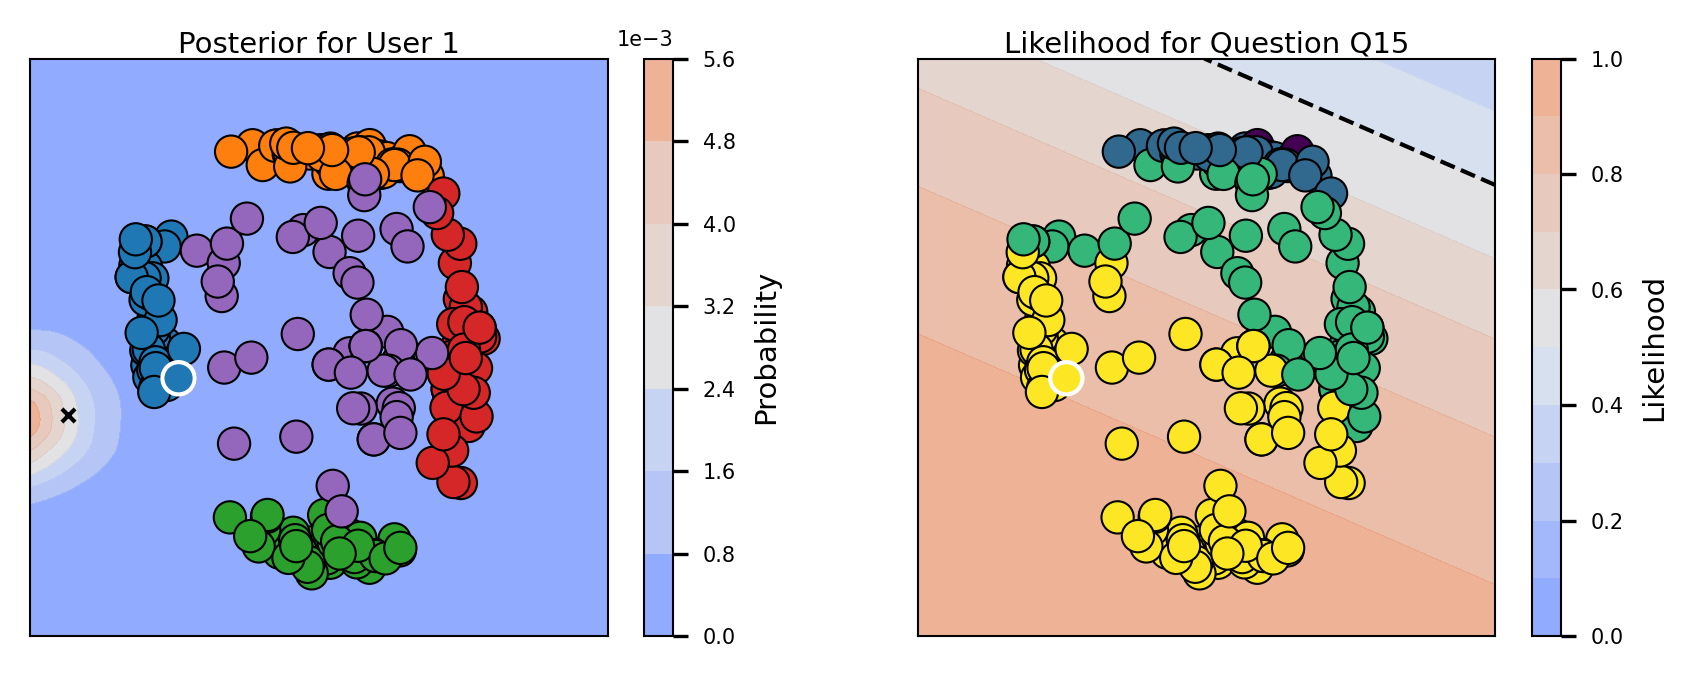

In [7]:
xplore.fit_models()
fig, (ax1, ax2) = plot_overview(xplore, question='Q15', user='1', colors=users.color)

We repeat these three steps for another four iterations and see how the mean absolute error goes down.

ixplore - INFO - 2026-03-14 13:07:48 - Iteration 1/4
ixplore - INFO - 2026-03-14 13:07:51 - Fit MAE: 0.0759, Fit accuracy: 0.9697
ixplore - INFO - 2026-03-14 13:07:51 - Iteration 2/4
ixplore - INFO - 2026-03-14 13:07:53 - Fit MAE: 0.0674, Fit accuracy: 0.9813
ixplore - INFO - 2026-03-14 13:07:53 - Iteration 3/4
ixplore - INFO - 2026-03-14 13:07:55 - Fit MAE: 0.0651, Fit accuracy: 0.9842
ixplore - INFO - 2026-03-14 13:07:55 - Iteration 4/4
ixplore - INFO - 2026-03-14 13:07:58 - Fit MAE: 0.0641, Fit accuracy: 0.9853
ixplore - INFO - 2026-03-14 13:07:58 - MAE: 0.0641, ACC: 0.9853


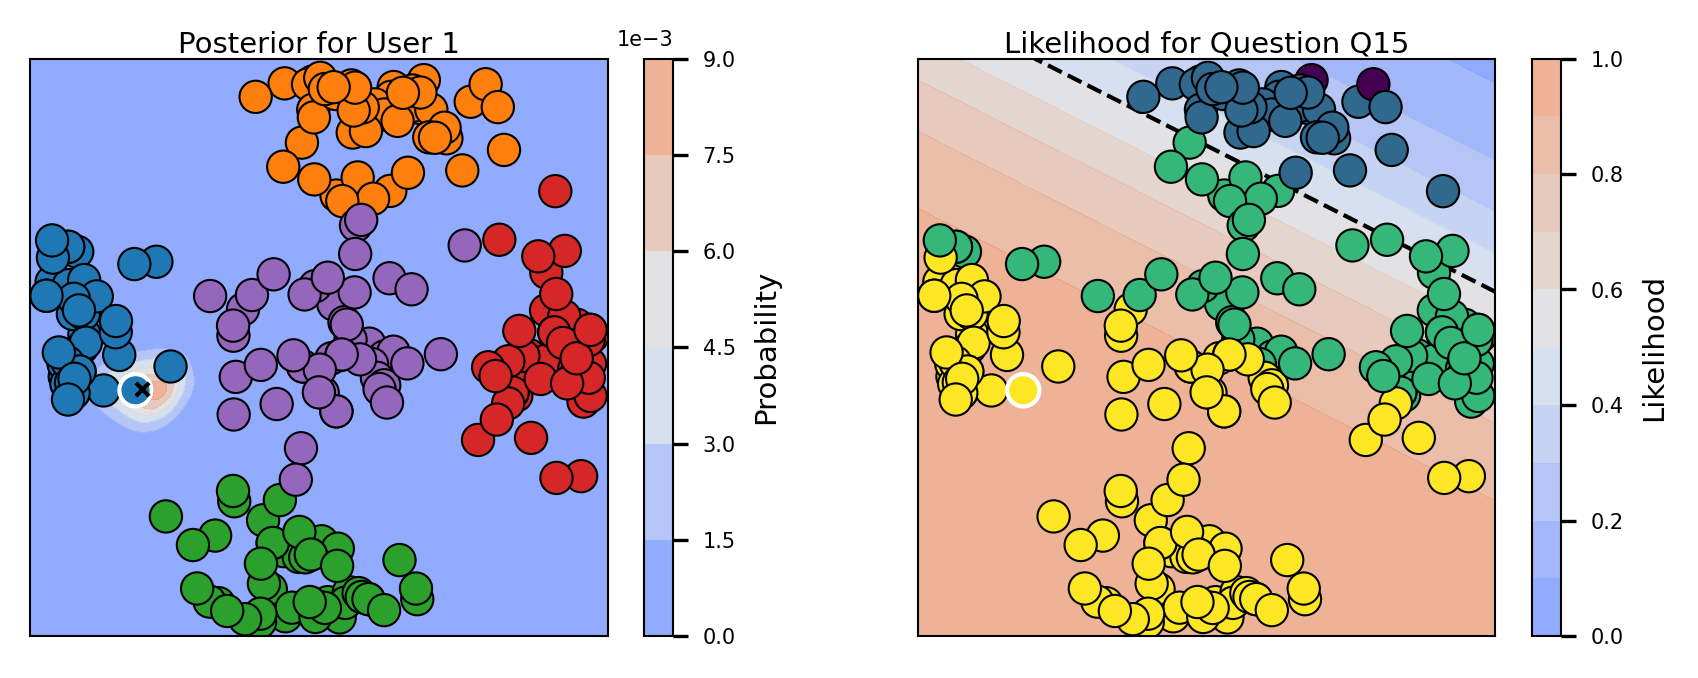

In [8]:
xplore.iterate(n_iterations=4)
fig, (ax1, ax2) = plot_overview(xplore, question='Q15', user='1', colors=users.color)

We apply a linear transformation (rotation/shear/scale) to the embedding to align with typical dimensions in political landscapes.

ixplore - INFO - 2026-03-14 13:07:58 - MAE: 0.0634, ACC: 0.9845


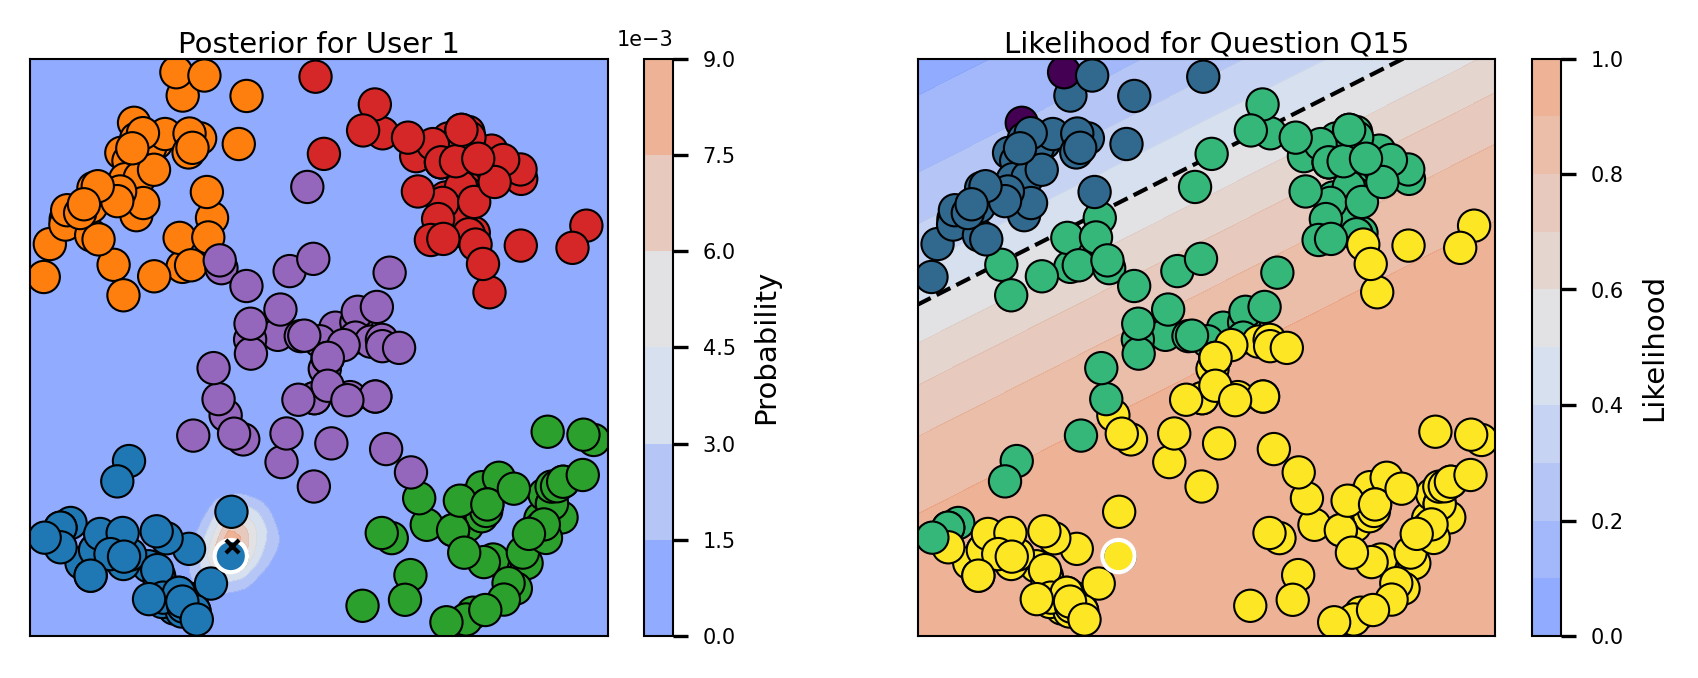

In [9]:
M = transformation_matrix(rotate=55, scale=(1.1, 1), order=('shear', 'rotate', 'scale'))
xplore.transform_embedding(M)
fig, (ax1, ax2) = plot_overview(xplore, question='Q15', user='1', colors=users.color)

Let's update the posteriors one more time and save this image for the README.

ixplore - INFO - 2026-03-14 13:07:59 - MAE: 0.0618, ACC: 0.9873


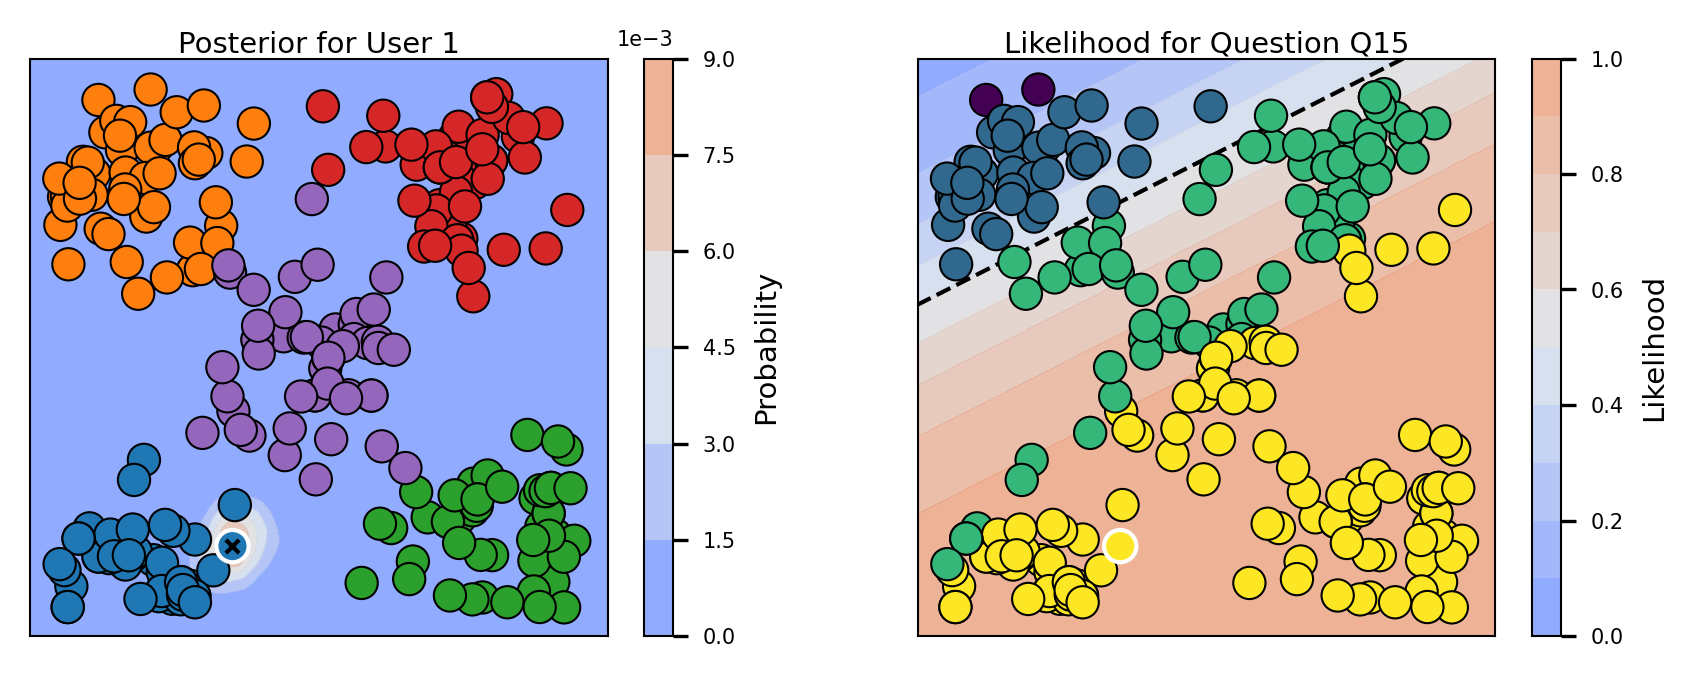

In [10]:
xplore.fit_posteriors()
fig, (ax1, ax2) = plot_overview(xplore, question='Q15', user='1', colors=users.color)
fig.savefig("../figures/overview.png", dpi=300, bbox_inches="tight")

### Initialize with transformation

We can then later initialize the model directly with this predefined transformation matrix.

ixplore - INFO - 2026-03-14 13:07:59 - Number of users for model: 250
ixplore - INFO - 2026-03-14 13:07:59 - Number of items: 70
ixplore - INFO - 2026-03-14 13:07:59 - Number of missing values: 0 (0.00%)
ixplore - INFO - 2026-03-14 13:07:59 - Grid created with resolution 100x100, total 10000 points
ixplore - INFO - 2026-03-14 13:07:59 - Prior set with mean [0 0] and covariance [1 0 0 1]
ixplore - INFO - 2026-03-14 13:07:59 - Random state set to 17
ixplore - INFO - 2026-03-14 13:07:59 - Initialized embedding with random values.
ixplore - INFO - 2026-03-14 13:07:59 - Fitted model parameters from embedding.
ixplore - INFO - 2026-03-14 13:07:59 - Iteration 1/5
ixplore - INFO - 2026-03-14 13:08:02 - Fit MAE: 0.1218, Fit accuracy: 0.9253
ixplore - INFO - 2026-03-14 13:08:02 - Iteration 2/5
ixplore - INFO - 2026-03-14 13:08:04 - Fit MAE: 0.0674, Fit accuracy: 0.9799
ixplore - INFO - 2026-03-14 13:08:04 - Iteration 3/5
ixplore - INFO - 2026-03-14 13:08:06 - Fit MAE: 0.0641, Fit accuracy: 0.983

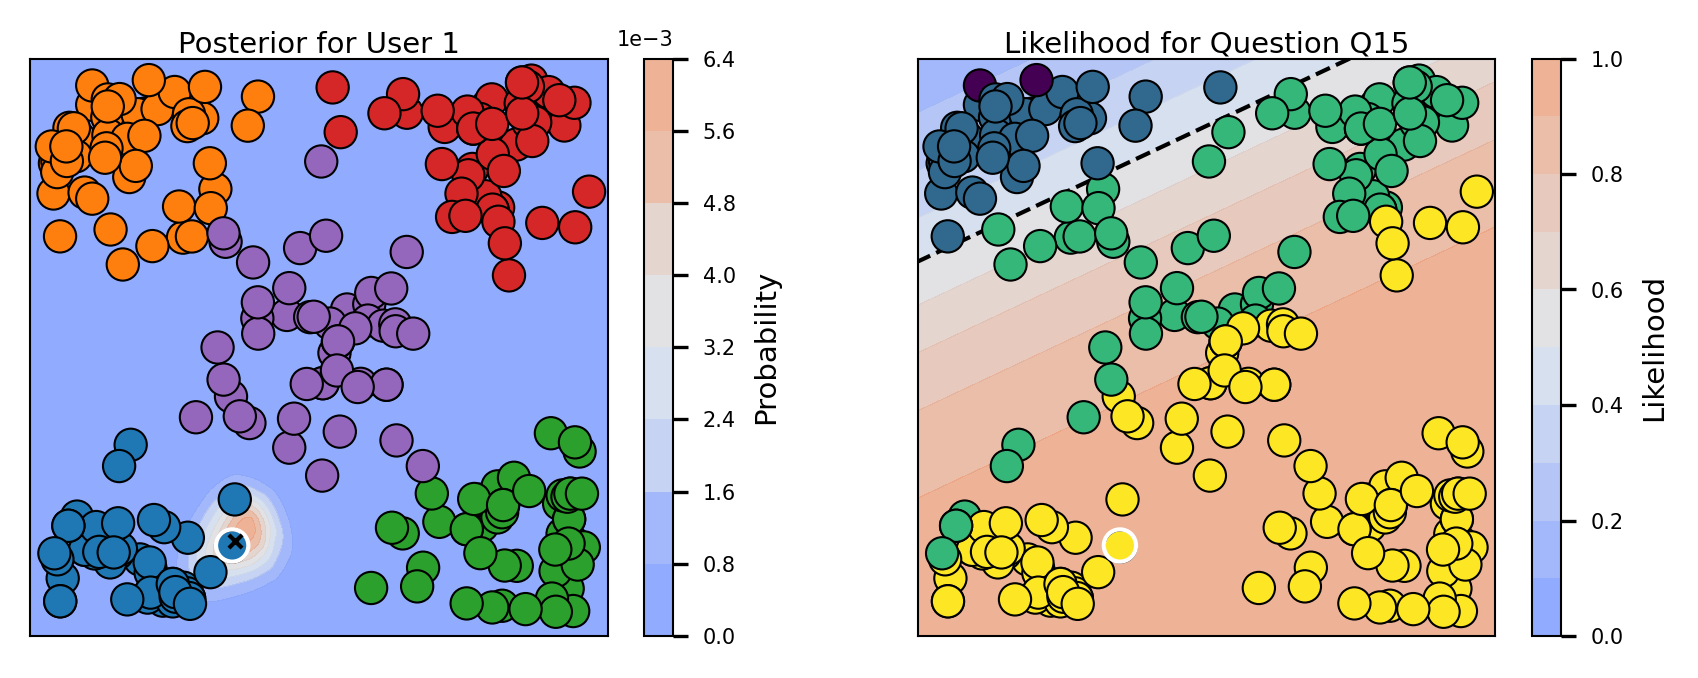

In [11]:
M = transformation_matrix(rotate=55, scale=(1.1, 1), order=('shear', 'rotate', 'scale'))

transformed_xplore = IXPLORE(reactions, pca_initialization=False, random_state=17, transformation=M)
transformed_xplore.iterate(n_iterations=5)
fig, (ax1, ax2) = plot_overview(transformed_xplore, question='Q15', user='1', colors=users.color)

We can save the embedding coordinates and model parameters to load them directly later.

In [12]:
path = '../data/pretrained_embedding_likert.csv'
transformed_xplore.get_embedding().to_csv(path)

path = '../data/pretrained_models_likert.csv'
transformed_xplore.get_item_parameters().to_csv(path)

### Initialize with PCA

We can directly initialize the embedding with PCA to speed up the convergence.

ixplore - INFO - 2026-03-14 13:08:11 - Number of users for model: 250
ixplore - INFO - 2026-03-14 13:08:11 - Number of items: 70
ixplore - INFO - 2026-03-14 13:08:11 - Number of missing values: 0 (0.00%)
ixplore - INFO - 2026-03-14 13:08:11 - Grid created with resolution 100x100, total 10000 points
ixplore - INFO - 2026-03-14 13:08:11 - Prior set with mean [0 0] and covariance [1 0 0 1]
ixplore - INFO - 2026-03-14 13:08:11 - Random state set to 17
ixplore - INFO - 2026-03-14 13:08:11 - Initialized embedding with PCA.
ixplore - INFO - 2026-03-14 13:08:11 - Fitted model parameters from embedding.
ixplore - INFO - 2026-03-14 13:08:12 - MAE: 0.0645, ACC: 0.9810


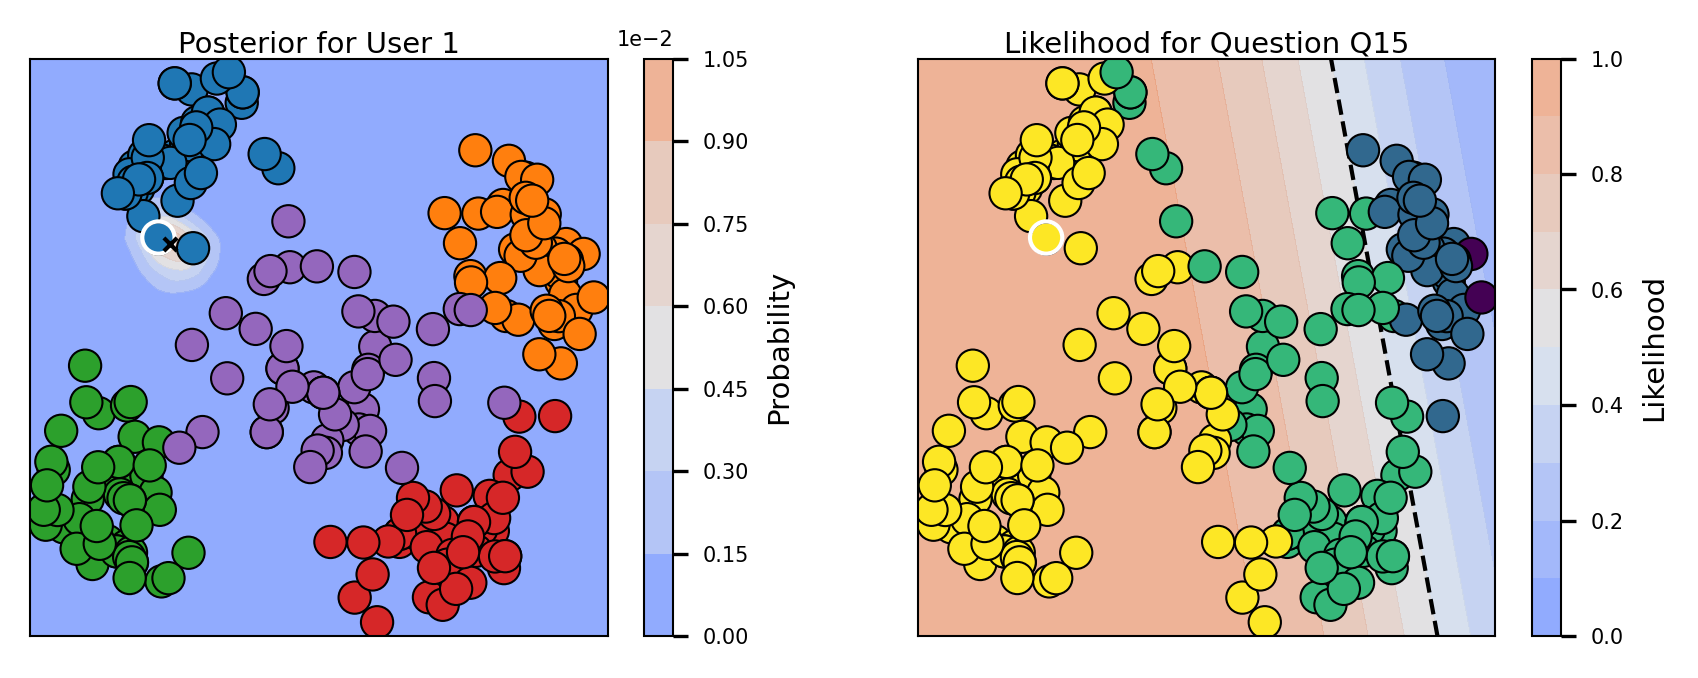

In [13]:
pca_xplore = IXPLORE(reactions, pca_initialization=True, random_state=17)
fig, (ax1, ax2) = plot_overview(pca_xplore, question='Q15', user='1', colors=users.color)

## Load model

We can load a model with pretrained embedding and/or item parameters.

ixplore - INFO - 2026-03-14 13:08:12 - Number of users for model: 250
ixplore - INFO - 2026-03-14 13:08:12 - Number of items: 70
ixplore - INFO - 2026-03-14 13:08:12 - Number of missing values: 0 (0.00%)
ixplore - INFO - 2026-03-14 13:08:12 - Grid created with resolution 100x100, total 10000 points
ixplore - INFO - 2026-03-14 13:08:12 - Prior set with mean [0 0] and covariance [1 0 0 1]
ixplore - INFO - 2026-03-14 13:08:12 - Random state set to 0
ixplore - INFO - 2026-03-14 13:08:12 - Used pretrained embedding.
ixplore - INFO - 2026-03-14 13:08:12 - Used pretrained model parameters.
ixplore - INFO - 2026-03-14 13:08:12 - MAE: 0.0629, ACC: 0.9853


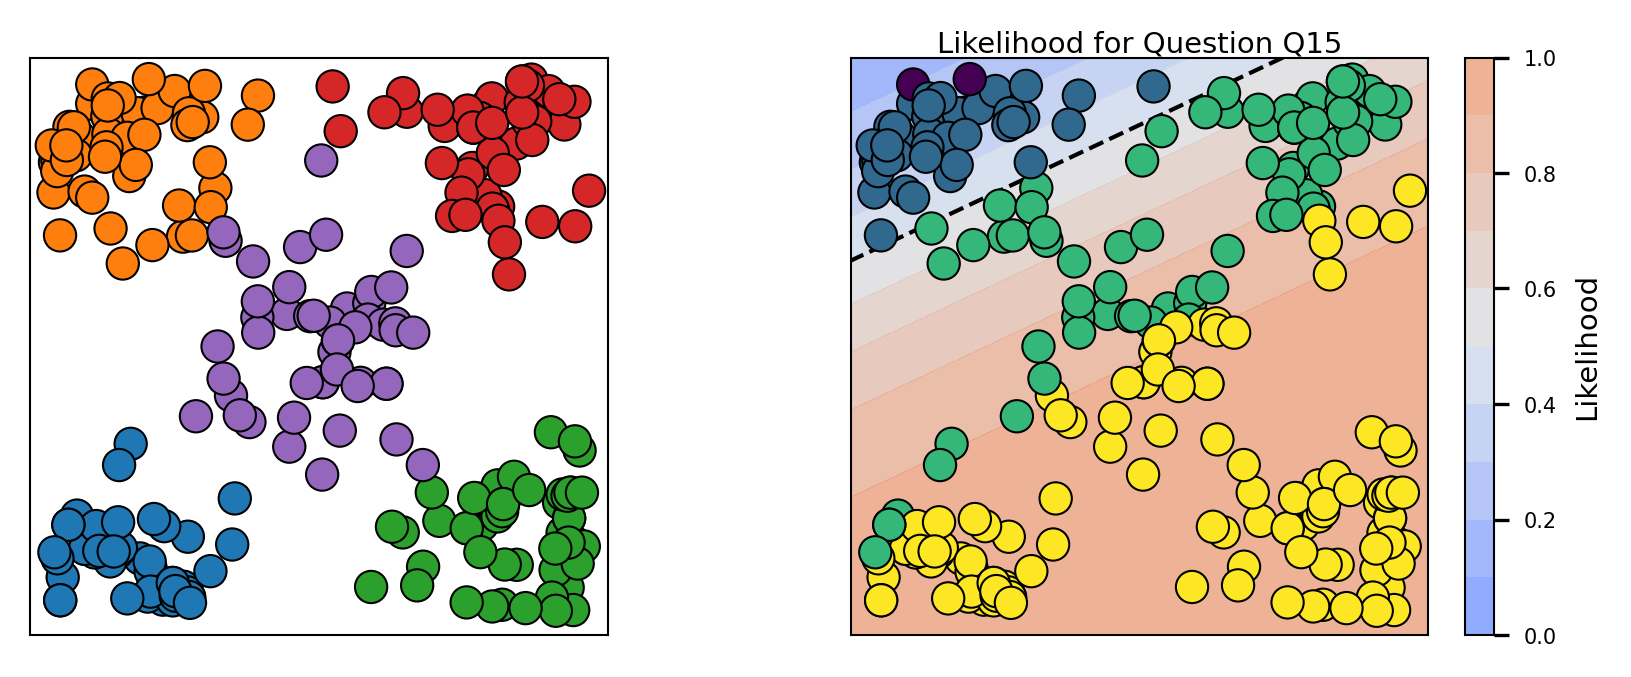

In [14]:
embedding = pd.read_csv('../data/pretrained_embedding_likert.csv', index_col=0)
models = pd.read_csv('../data/pretrained_models_likert.csv', index_col=0)
loaded_xplore = IXPLORE(reactions, 
                        pretrained_embedding=embedding,
                        pretrained_models=models)
fig, (ax1, ax2) = plot_overview(loaded_xplore, question='Q15', user=None, colors=users.color)

We can also embed a new user that has only answered one question and see where they would be located in the embedding space. 

ixplore - INFO - 2026-03-14 13:08:12 - MAE: 0.0629, ACC: 0.9853


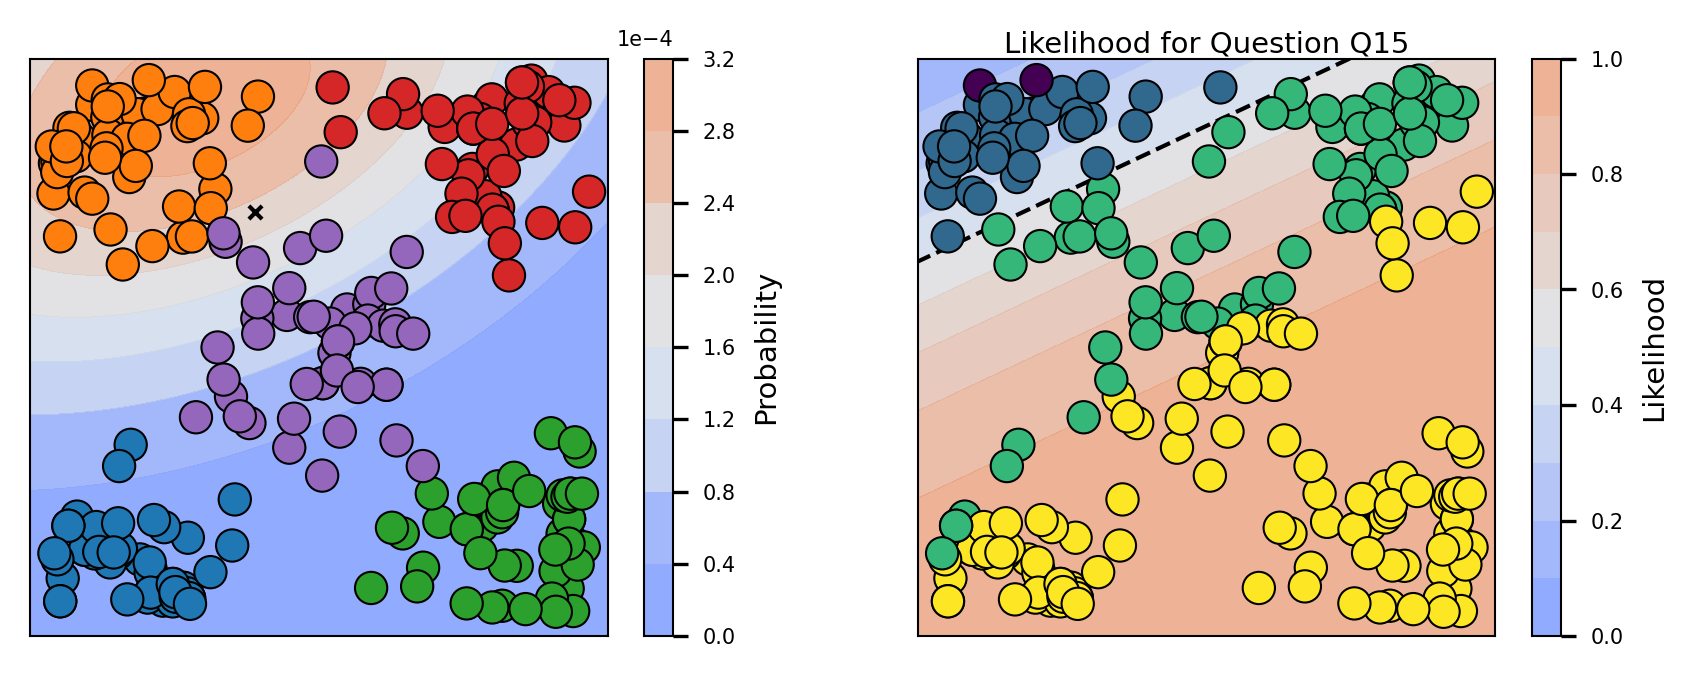

In [15]:
new_user = pd.Series({'Q15':0}, name='new_user')
fig, (ax1, ax2) = plot_overview(loaded_xplore, question='Q15', user=None, colors=users.color)
fig, ax1 = plot_posterior(loaded_xplore, new_user, ax=ax1) 

Let's say, we want to create a user that is at the very left of the embedding space. We can then predict answers for this position.

In [16]:
answers = loaded_xplore.predict(np.array([[-0.55,0.1]])).flatten().round()
new_user = pd.Series(answers, index=loaded_xplore.items, name='new_user')
new_user.head()

Q1    1.0
Q2    0.0
Q3    1.0
Q4    0.0
Q5    1.0
Name: new_user, dtype: float64

If we embed this user, we see that they end up in the left area.

ixplore - INFO - 2026-03-14 13:08:12 - MAE: 0.0629, ACC: 0.9853


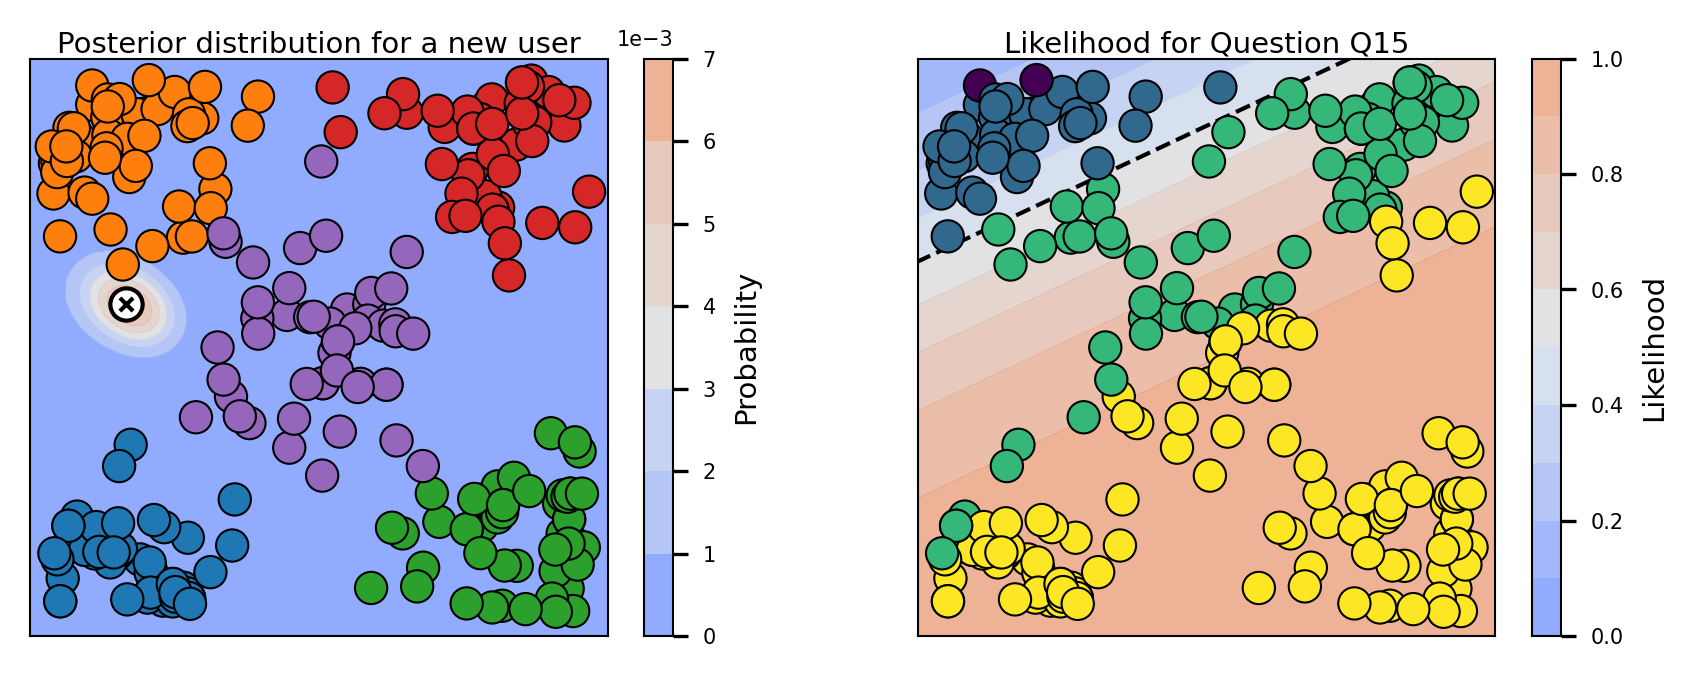

In [17]:
fig, (ax1, ax2) = plot_overview(loaded_xplore, question='Q15', user=None, colors=users.color)
x, y = loaded_xplore.embed_new_user(new_user)
ax1.scatter(x, y, color='white', edgecolors='black', s=60, zorder=5)
fig, ax1 = plot_posterior(loaded_xplore, new_user, ax=ax1) 
ax1.set_title("Posterior distribution for a new user")
fig.savefig("../figures/overview_new_user.png", dpi=300, bbox_inches="tight")